## Introduction

This notebook trains a **Swin Transformer Tiny** model for skin lesion classification, using a two-phase fine-tuning strategy (head warm-up, then staged backbone unfreezing) plus MixUp/CutMix, RandAugment, AMP, and macro-F1-based early stopping.

## Setup

In [1]:
import os
import json
from datetime import datetime, timezone
import boto3
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from skin_lesion_project.processing.image_processing import training_data_transforms, test_val_transforms
from skin_lesion_project.datasets.dataloader import create_dataloaders
from skin_lesion_project.models.swin import get_swin_t
from skin_lesion_project.training.train import train

/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

NUM_CLASSES = 8
IMAGE_SIZE = 224
BATCH_SIZE = 32

# --- Phase 1: head warm-up (backbone frozen) ---
EPOCHS_WARMUP = 15
HEAD_LR_WARMUP = 1e-3
WEIGHT_DECAY = 0.05

# --- Phase 2: staged fine-tuning (last 2 Swin stages unfrozen) ---
EPOCHS_FINETUNE = 100
HEAD_LR_FINETUNE = 5e-5
BACKBONE_LR_FINETUNE = 5e-6
FINETUNE_WARMUP_EPOCHS = 5
UNFREEZE_STAGES = 1

EARLY_STOPPING_PATIENCE = 1000

Device : cuda
GPU : NVIDIA A100 80GB PCIe


In [3]:
DEVICE

device(type='cuda')

## Data Loaders

In [4]:
train_loader, val_loader, class_weights = create_dataloaders(
    train_transform=training_data_transforms(image_size=IMAGE_SIZE),
    val_transform=test_val_transforms(image_size=IMAGE_SIZE),
    train_image_dir="/home/shadeform/data/train",
    train_label_file="/home/shadeform/data/labels/mappings.pkl",
    val_image_dir="/home/shadeform/data/test",
    val_label_file="/home/shadeform/data/labels/mappings_test.pkl",
    batch_size=BATCH_SIZE,
    downsample_classes={
        "NV": 5000,
        "MEL": 5000,
    },
    use_weighted_sampler=False,
)


Original Training Distribution
MEL  : 5321
NV   : 17486
BCC  : 3316
AK   : 1056
BKL  : 2829
DF   : 239
VASC : 253
SCC  : 431

Balanced Training Distribution
MEL  : 5000
NV   : 5000
BCC  : 3316
AK   : 1056
BKL  : 2829
DF   : 239
VASC : 253
SCC  : 431

Training Images : 18124
Training Images   : 18124
Validation Images : 8238
Batch Size        : 32
Workers           : 16
Weighted Sampler  : False
Downsampling      : Enabled


## Images

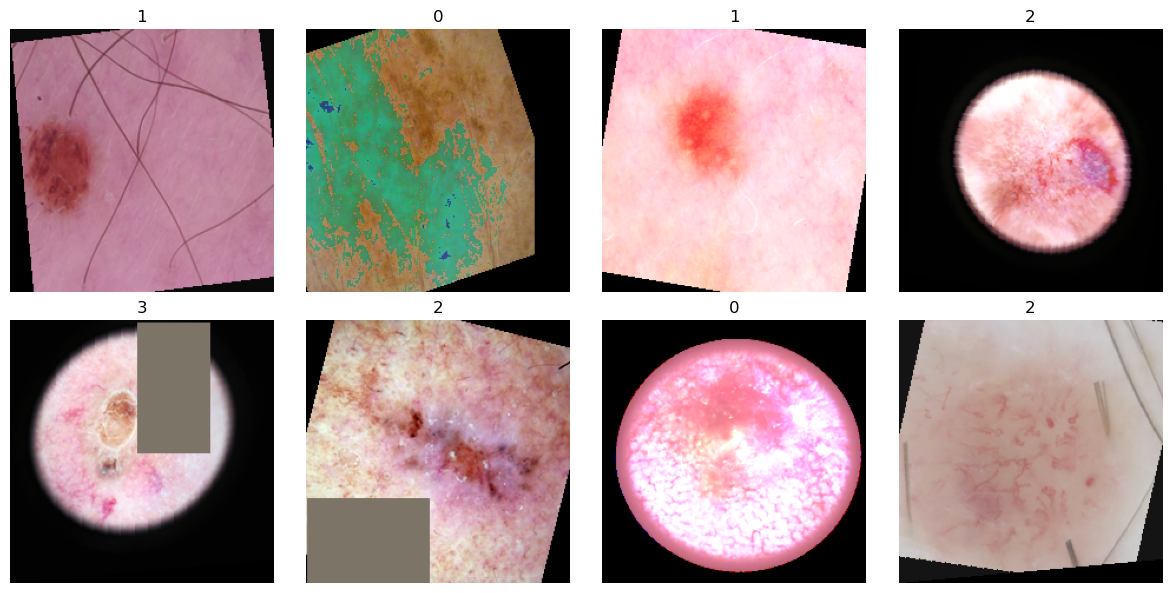

In [5]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu()
    image = image * std + mean
    image = image.clamp(0, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.tight_layout()
plt.show()

## Swin Transformer Tiny Model

In [6]:
model = get_swin_t(num_classes=NUM_CLASSES, pretrained=True, head_dropout=0.5)

model.freeze_backbone()
model.to(DEVICE)
model.summary()

Model            : Swin Transformer Tiny
Output Classes   : 8
Feature Dimension: 768
Trainable Params : 6,152


## Phase 1: Head Warm-Up (backbone frozen)

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.get_param_groups(head_lr=1e-4, backbone_lr=1e-5), betas=(0.9,0.999))
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_WARMUP)

history_warmup = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_WARMUP,
    checkpoint_path="checkpoints/swin_t_head_warmup.pt",
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    num_classes=NUM_CLASSES,
    use_mixup=True, mixup_alpha=0.2, cutmix_alpha=1.0, mixup_prob=0.5,
    label_smoothing=0.1, monitor="macro_f1",
)

/home/shadeform/skin-lesion-project/skin_lesion_project/training/train.py:163: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")
                                                                                                                                                                                                               

Epoch   1/15 | train_loss 1.7365 acc 0.3568 | val_loss 1.6110 acc 0.3995 macro_f1 0.1670 | lr 9.89e-05
  -> new best (macro_f1=0.1670), checkpoint saved.


Epoch   2/15 | train_loss 1.5977 acc 0.4344 | val_loss 1.5929 acc 0.4065 macro_f1 0.1790 | lr 9.57e-05
  -> new best (macro_f1=0.1790), checkpoint saved.


Epoch   3/15 | train_loss 1.5552 acc 0.4499 | val_loss 1.5711 acc 0.4229 macro_f1 0.1949 | lr 9.05e-05
  -> new best (macro_f1=0.1949), checkpoint saved.


Epoch   4/15 | train_loss 1.5287 acc 0.4578 | val_loss 1.5991 acc 0.4142 macro_f1 0.1974 | lr 8.35e-05
  -> new best (macro_f1=0.1974), checkpoint saved.


...

Epoch  11/15 | train_loss 1.4939 acc 0.4787 | val_loss 1.5688 acc 0.4359 macro_f1 0.2151 | lr 1.65e-05


Epoch  12/15 | train_loss 1.4947 acc 0.4811 | val_loss 1.5690 acc 0.4364 macro_f1 0.2158 | lr 9.55e-06


Epoch  13/15 | train_loss 1.4927 acc 0.4884 | val_loss 1.5691 acc 0.4376 macro_f1 0.2167 | lr 4.32e-06


Epoch  14/15 | train_loss 1.4951 acc 0.4810 | val_loss 1.5692 acc 0.4385 macro_f1 0.2172 | lr 1.09e-06


Epoch  15/15 | train_loss 1.4889 acc 0.4786 | val_loss 1.5699 acc 0.4378 macro_f1 0.2172 | lr 0.00e+00


## Phase 2: Staged Fine-Tuning (last N Swin stages unfrozen)

In [8]:
model.load_state_dict(torch.load("checkpoints/swin_t_head_warmup.pt", map_location=DEVICE))
model.unfreeze_last_stages(num_stages=UNFREEZE_STAGES)
model.summary()

optimizer = AdamW(model.get_param_groups(
    head_lr=HEAD_LR_FINETUNE,
    backbone_lr=BACKBONE_LR_FINETUNE,
    weight_decay=WEIGHT_DECAY,
))
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE - FINETUNE_WARMUP_EPOCHS)

history_finetune = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_FINETUNE,
    checkpoint_path="checkpoints/swin_t_finetuned.pt",
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    num_classes=NUM_CLASSES,
    use_mixup=True, mixup_alpha=0.2, cutmix_alpha=1.0, mixup_prob=0.5,
    label_smoothing=0.1, warmup_epochs=FINETUNE_WARMUP_EPOCHS, monitor="macro_f1")

/tmp/ipykernel_56218/2293077679.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("checkpoints/swin_t_head_warmup.pt", map_location=DEVICE

Model            : Swin Transformer Tiny
Output Classes   : 8
Feature Dimension: 768
Trainable Params : 15,374,264


Epoch   1/100 | train_loss 1.4867 acc 0.4808 | val_loss 1.5767 acc 0.4378 macro_f1 0.2207 | lr 1.00e-05
  -> new best (macro_f1=0.2207), checkpoint saved.


Epoch   2/100 | train_loss 1.4746 acc 0.4887 | val_loss 1.5810 acc 0.4394 macro_f1 0.2268 | lr 2.00e-05
  -> new best (macro_f1=0.2268), checkpoint saved.


Epoch   3/100 | train_loss 1.4590 acc 0.4893 | val_loss 1.5669 acc 0.4463 macro_f1 0.2392 | lr 3.00e-05
  -> new best (macro_f1=0.2392), checkpoint saved.


...

Epoch  96/100 | train_loss 1.1922 acc 0.6084 | val_loss 1.5775 acc 0.5340 macro_f1 0.3922 | lr 2.18e-07


Epoch  97/100 | train_loss 1.1758 acc 0.6194 | val_loss 1.5774 acc 0.5339 macro_f1 0.3921 | lr 1.23e-07


Epoch  98/100 | train_loss 1.1816 acc 0.6101 | val_loss 1.5778 acc 0.5337 macro_f1 0.3920 | lr 5.47e-08


Epoch  99/100 | train_loss 1.1809 acc 0.6046 | val_loss 1.5778 acc 0.5337 macro_f1 0.3920 | lr 1.37e-08


Epoch 100/100 | train_loss 1.1792 acc 0.6183 | val_loss 1.5778 acc 0.5337 macro_f1 0.3920 | lr 0.00e+00


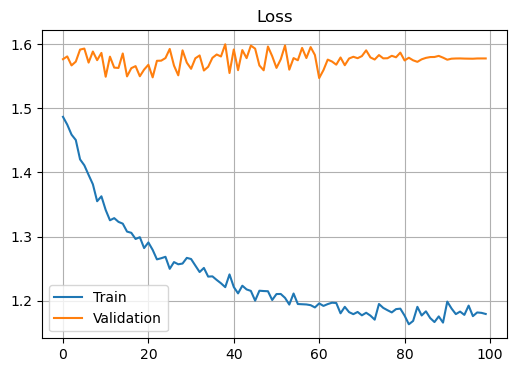

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["train_loss"], label="Train")
plt.plot(history_finetune["val_loss"], label="Validation")
plt.title("Loss")
plt.grid(True)
plt.legend()
plt.show()

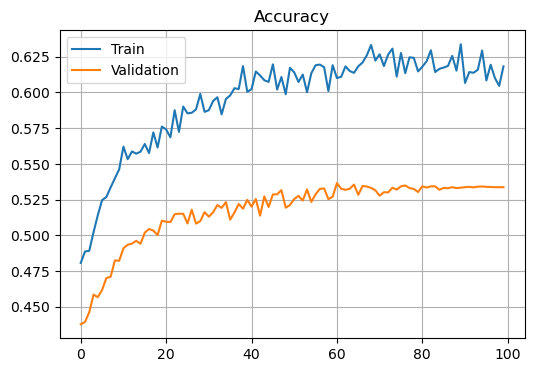

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["train_accuracy"], label="Train")
plt.plot(history_finetune["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

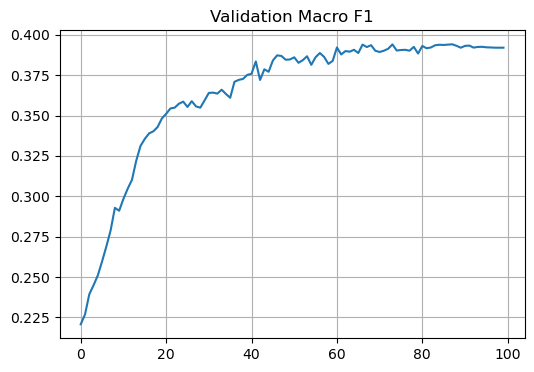

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["macro_f1"])
plt.title("Validation Macro F1")
plt.grid(True)
plt.show()

In [12]:
print(f"Best Validation Accuracy : {max(history_finetune['val_accuracy']):.4f}")
print(f"Best Validation Macro F1 : {max(history_finetune['macro_f1']):.4f}")

Best Validation Accuracy : 0.5367
Best Validation Macro F1 : 0.3941


## Model Saving

In [13]:
BUCKET_NAME = "skin-lesion-data-bucket"
MODEL_FOLDER = "models/swin_t"
s3 = boto3.client("s3")

In [14]:
os.makedirs("saved_models/swin_t", exist_ok=True)

In [15]:
checkpoint = {
    "model_name": "SwinTransformerTiny",
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "class_to_idx": {
        "MEL": 0,
        "NV": 1,
        "BCC": 2,
        "AK": 3,
        "BKL": 4,
        "DF": 5,
        "VASC": 6,
        "SCC": 7,
    },
    "num_classes": NUM_CLASSES,
}

torch.save(checkpoint, "saved_models/swin_t/swin_t_checkpoint.pth")

In [16]:
class_mapping = {
    0: "MEL",
    1: "NV",
    2: "BCC",
    3: "AK",
    4: "BKL",
    5: "DF",
    6: "VASC",
    7: "SCC",
}

with open("saved_models/swin_t/class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=4)

In [17]:
config = {
    "model_name": "SwinTransformerTiny",
    "architecture": "Swin-T",
    "version": "1.0.0",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR (with linear warmup)",
    "head_lr_finetune": HEAD_LR_FINETUNE,
    "backbone_lr_finetune": BACKBONE_LR_FINETUNE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "epochs_warmup": EPOCHS_WARMUP,
    "epochs_finetune": EPOCHS_FINETUNE,
    "unfreeze_stages": UNFREEZE_STAGES,
    "loss": "CrossEntropyLoss / soft-target CE (MixUp+CutMix)",
    "label_smoothing": 0.1,
    "mixup_alpha": 0.2,
    "cutmix_alpha": 1.0,
    "classes": [
        "MEL",
        "NV",
        "BCC",
        "AK",
        "BKL",
        "DF",
        "VASC",
        "SCC",
    ],
}

with open("saved_models/swin_t/model_config.json", "w") as f:
    json.dump(config, f, indent=4)

In [18]:
history_df = pd.DataFrame(history_finetune)
history_df.to_csv("saved_models/swin_t/training_history.csv", index=False)

In [19]:
metrics = {
    "best_validation_accuracy": float(max(history_finetune["val_accuracy"])),
    "best_macro_f1": float(max(history_finetune["macro_f1"])),
    "epochs": len(history_finetune["val_accuracy"]),
}

with open("saved_models/swin_t/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

/tmp/ipykernel_56218/779804797.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("checkpoints/swin_t_finetuned.pt", map_location=DEVICE)


<Figure size 1000x800 with 0 Axes>

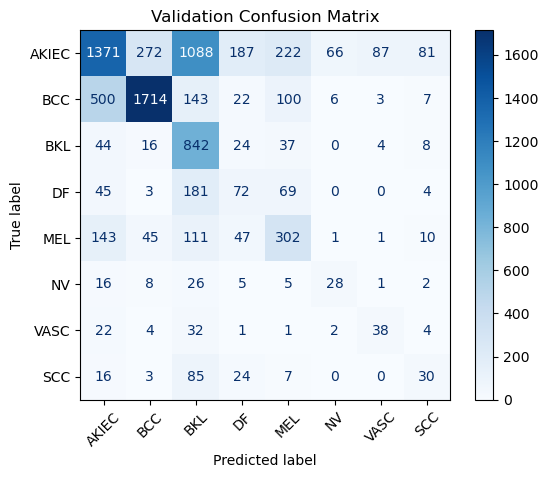

              precision    recall  f1-score   support

       AKIEC     0.6356    0.4063    0.4958      3374
         BCC     0.8300    0.6870    0.7518      2495
         BKL     0.3357    0.8636    0.4835       975
          DF     0.1885    0.1925    0.1905       374
         MEL     0.4065    0.4576    0.4305       660
          NV     0.2718    0.3077    0.2887        91
        VASC     0.2836    0.3654    0.3193       104
         SCC     0.2055    0.1818    0.1929       165

    accuracy                         0.5337      8238
   macro avg     0.3947    0.4327    0.3941      8238
weighted avg     0.6033    0.5337    0.5422      8238



In [21]:
model.load_state_dict(
    torch.load("checkpoints/swin_t_finetuned.pt", map_location=DEVICE)
)
model.to(DEVICE)
model.eval()

# ---------------------------------------------------
# Get predictions
# ---------------------------------------------------
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

class_names = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC",
    "SCC",
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Validation Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

In [20]:
files_to_upload = {
    "saved_models/swin_t/swin_t_checkpoint.pth":
        f"{MODEL_FOLDER}/swin_t_checkpoint.pth",

    "saved_models/swin_t/model_config.json":
        f"{MODEL_FOLDER}/model_config.json",

    "saved_models/swin_t/class_mapping.json":
        f"{MODEL_FOLDER}/class_mapping.json",

    "saved_models/swin_t/training_history.csv":
        f"{MODEL_FOLDER}/training_history.csv",

    "saved_models/swin_t/metrics.json":
        f"{MODEL_FOLDER}/metrics.json",
}

for local_file, s3_key in files_to_upload.items():
    s3.upload_file(local_file, BUCKET_NAME, s3_key)
    print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

print("All model artifacts uploaded successfully!")

Uploaded -> s3://skin-lesion-data-bucket/models/swin_t/swin_t_checkpoint.pth
Uploaded -> s3://skin-lesion-data-bucket/models/swin_t/model_config.json
Uploaded -> s3://skin-lesion-data-bucket/models/swin_t/class_mapping.json
Uploaded -> s3://skin-lesion-data-bucket/models/swin_t/training_history.csv
Uploaded -> s3://skin-lesion-data-bucket/models/swin_t/metrics.json
All model artifacts uploaded successfully!
